In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [14]:
titanic = sns.load_dataset("titanic")
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:

features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [16]:
#Handle missing value
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [17]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [18]:
X = titanic[features]
y = titanic[target]

In [22]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.3,random_state = 42
)

In [23]:
#decision tree classifier model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.7574626865671642


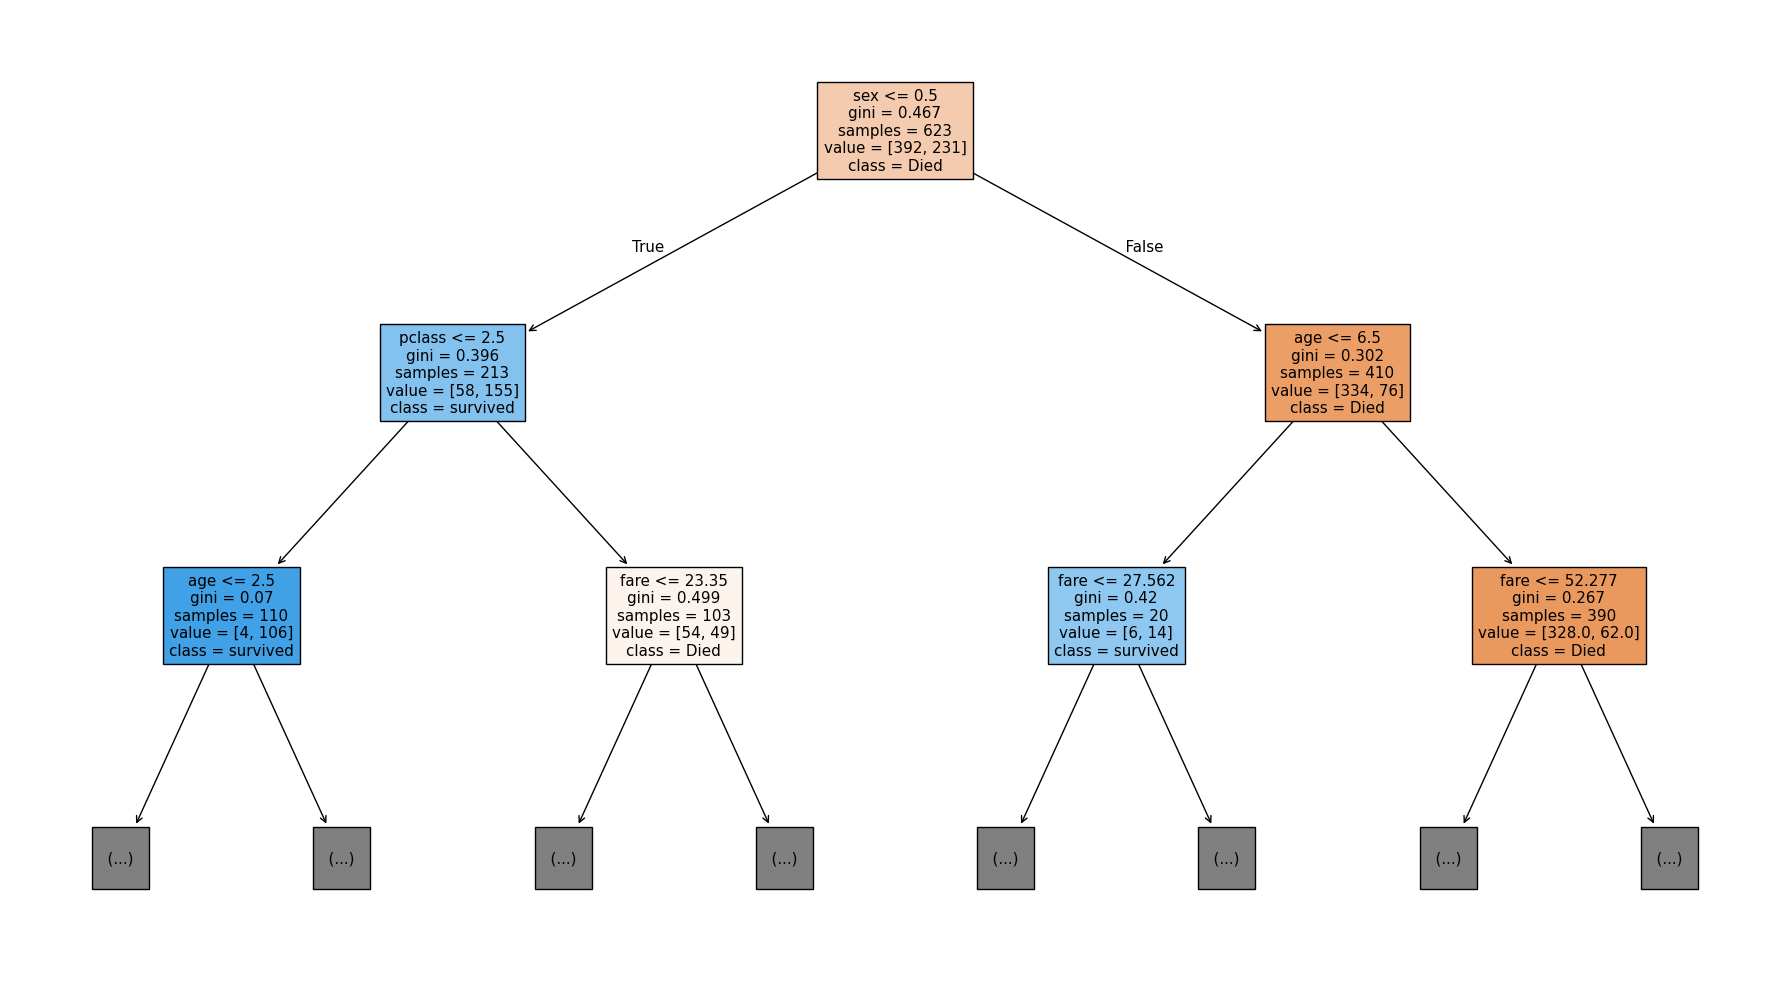

In [29]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","survived"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()
plt.show()